# Natural Gas Price Modelling

**Goal:** forecast the next 12 months of natural gas prices from 4 years of monthly data.

**How this notebook reads**
- **Part 1: The submission model:** a human-assumed trend + sine model, motivated purely by the visual shape of the raw data.
- **Part 2: Does the machine agree?** six standard ML regressors are thrown at the same problem to see whether they find anything the eye missed.

In [279]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from lightgbm import LGBMRegressor as lgbm
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import curve_fit

## 0. Setup

Imports and the raw monthly price series.

In [280]:
df = pd.read_csv("../data/Nat_Gas.csv")

## 1. The raw data

- 48 monthly observations: just `Dates` and `Prices`.
- Quick sanity check with `head()` / `describe()`.
- Prices sit in a tight ~9.8–12.8 band around a mean of ~11.2.

In [281]:
df.head()

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


In [282]:
df.describe()

,Prices
count,48.000000
mean,11.207083
std,0.757897
min,9.840000
25%,10.650000
50%,11.300000
75%,11.625000
max,12.800000


### The visual assumption

Plotting price against time, two things jump out:

- The series **rises gently** over the ~4 years, a slow upward trend.
- On top of the trend it **oscillates on a roughly yearly rhythm**, winters up, shoulder-months down.

👉 To the eye this looks like a **trend + a sine wave**. That single observation is the seed of the whole submission.

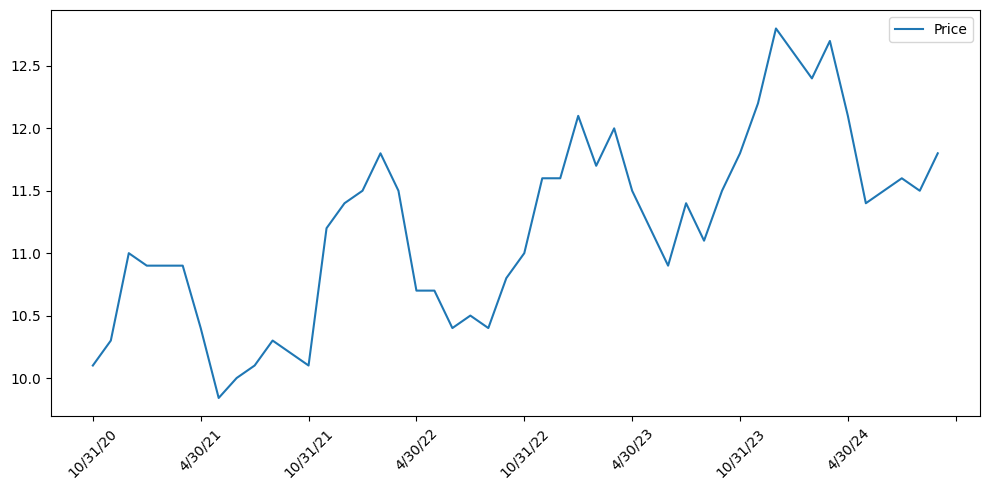

In [283]:
plt.figure(figsize=(10, 5))

plt.plot(df["Dates"], df["Prices"], label="Price")

# Show at most 10 x-axis ticks
ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(10))

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## 2. The submission model, trend + sine

A deliberately *human-designed* model, read straight off the shape of the plot:

$$\hat{y}(t) = a + b\,t + A\,\sin(\omega t + \phi)$$

- `a` a baseline level (first price)
- `b = 0.05` a gentle upward slope per month
- `A = 0.8` a swing size of the seasonal cycle
- `ω = 2π/12` a one full cycle every **12 months**
- `φ = 0` a phase of the cycle

Parameters are set **by hand** a chosen to trace the curve, no fitting, just eyeballing. The overlay tracks the seasonal ups and downs, which is exactly what a forecaster needs to extrapolate the next year.

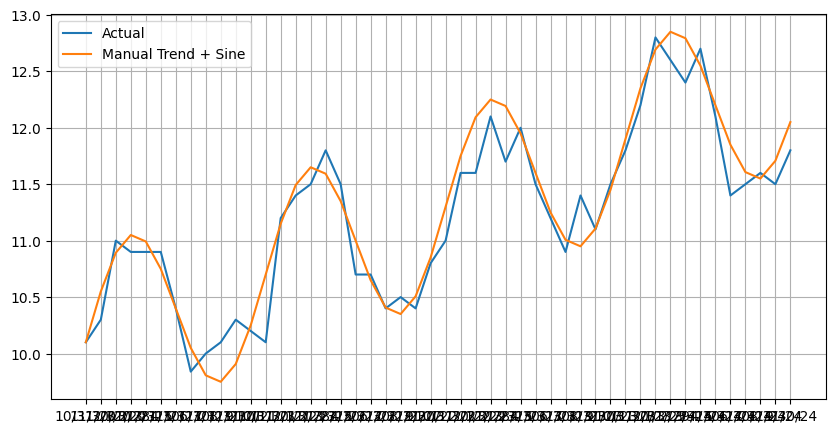

In [284]:
# time index
t = np.arange(len(df))
y = df["Prices"].values

# ----------------------------
# MANUAL PARAMETERS (edit these)
# ----------------------------
a = y[0]          # baseline level
b = 0.05          # slope (trend per step)
A = 0.8           # oscillation amplitude
w = 2 * np.pi / 12  # cycle length (12-month seasonality)
phi = 0           # phase shift

# ----------------------------
# model
# ----------------------------
def model(t):
    return a + b*t + A * np.sin(w*t + phi)

y_fit = model(t)

# ----------------------------
# plot
# ----------------------------
plt.figure(figsize=(10,5))
plt.plot(df["Dates"], y, label="Actual")
plt.plot(df["Dates"], y_fit, label="Manual Trend + Sine")
plt.legend()
plt.grid(True)
plt.show()

## 3. Does the machine agree?

The sine model is a **human assumption**, it comes from *looking* at the data, not from any algorithm.

So the natural question: **hand this to standard ML regressors, do they find anything better?**

Plan:
- Try **six models**, Linear, Polynomial, Ridge, Lasso, SVR (RBF), KNN.
- Hold out the **last 12 months** as a test set.
- Score everything against a **naive "last value" baseline**.

### 3.1 Seasonality, checked numerically

Before modelling, quantify the monthly rhythm:

- `monthly_change_statistics`, average month-to-month move per calendar month.
- Clear seasonal signature: strong **negative** moves in Apr–May, strong **positive** moves in Nov–Dec.
- The small-multiples of a Normal per month show how variable each month's change is.

This confirms the yearly cycle the sine term is trying to capture.

In [285]:
import pandas as pd

def monthly_change_statistics(df, date_col="Dates", value_col="Prices"):
    df = df.copy()

    # Convert dates
    df[date_col] = pd.to_datetime(df[date_col])

    # Sort by date
    df = df.sort_values(date_col)

    # Month-to-month change
    df["Monthly_Change"] = df[value_col].diff()

    # Extract year and month
    df["Year"] = df[date_col].dt.year
    df["Month"] = df[date_col].dt.month

    # Aggregate by calendar month
    summary = (
        df.groupby("Month")["Monthly_Change"]
        .agg(
            Average="mean",
            Std="std",
            Minimum="min",
            Maximum="max"
        )
        .round(2)
    )

    return summary

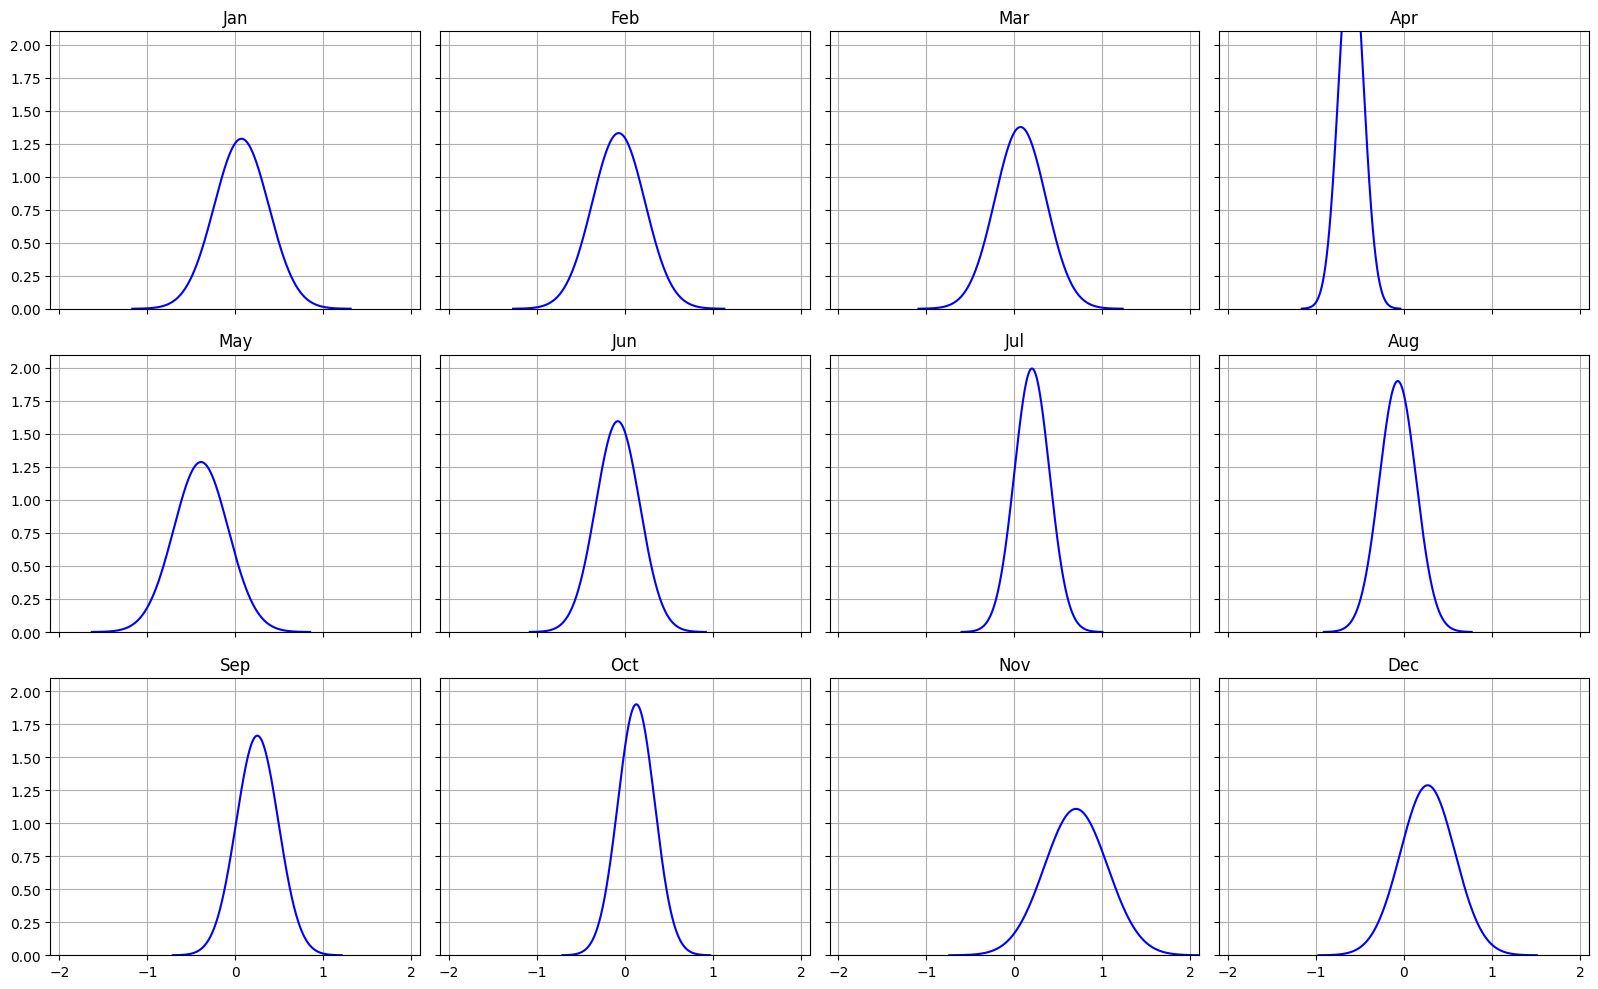

In [286]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, (_, row) in enumerate(stat.iterrows()):
    mean = row["Average"]
    std_dev = row["Std"]

    if np.isnan(std_dev) or std_dev == 0:
        continue

    x = np.linspace(mean - 4 * std_dev, mean + 4 * std_dev, 1000)
    y = stats.norm.pdf(x, mean, std_dev)

    ax = axes[i]
    ax.plot(x, y, color="blue", label="Normal")
    ax.set_title(month_names[i])

    # Use the same limits for every subplot
    ax.set_xlim(-2.1, 2.1)   # Adjust if you meant something else
    ax.set_ylim(0, 2.1)

    ax.grid(True)

plt.tight_layout()
plt.show()

### 3.2 Log returns

Switch from price *levels* to **log returns** (month-over-month), the more standard modelling target:

- Returns hover around zero with no obvious drift.
- The histogram sits reasonably under a fitted Normal, no fat surprises.
- `Log_Return` becomes the single feature fed to the regressors.

In [287]:
df["Dates"] = pd.to_datetime(df["Dates"])
df = df.sort_values("Dates")

df["Log_Return"] = np.log(df["Prices"] / df["Prices"].shift(1))

C:\Users\aqeel\AppData\Local\Temp\ipykernel_15876\3130376584.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dates"] = pd.to_datetime(df["Dates"])


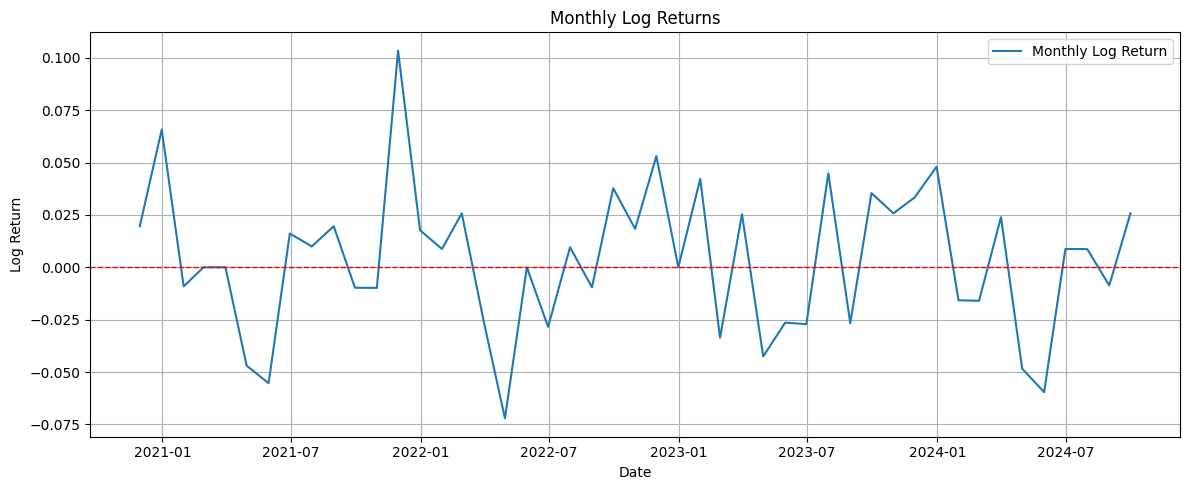

In [288]:
# Prepare data
df["Dates"] = pd.to_datetime(df["Dates"])
df = df.sort_values("Dates")

# Compute log returns
df["Log_Return"] = np.log(df["Prices"]).diff()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(df["Dates"], df["Log_Return"], label="Monthly Log Return")
plt.axhline(0, color="red", linestyle="--", linewidth=1)

plt.title("Monthly Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

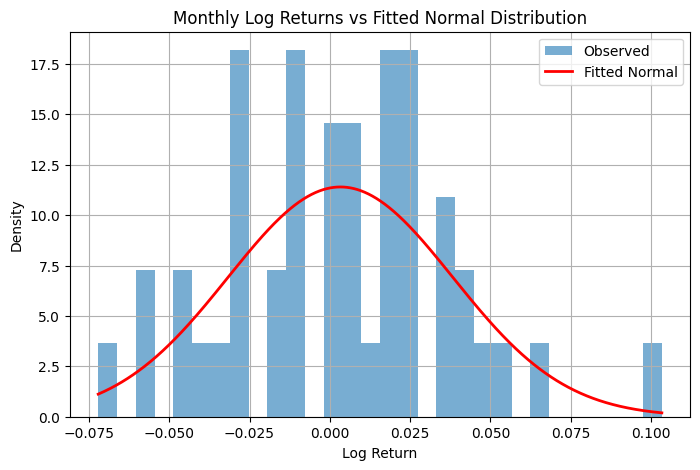

In [289]:
from scipy.stats import norm

returns = df["Log_Return"].dropna()

mean = returns.mean()
std = returns.std()

x = np.linspace(returns.min(), returns.max(), 1000)
y = norm.pdf(x, mean, std)

plt.figure(figsize=(8, 5))
plt.hist(returns, bins=30, density=True, alpha=0.6, label="Observed")
plt.plot(x, y, "r", linewidth=2, label="Fitted Normal")

plt.title("Monthly Log Returns vs Fitted Normal Distribution")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.grid(True)
plt.legend()
plt.show()

In [290]:
df.tail()

,Dates,Prices,Log_Return
43,2024-05-31,11.4,-0.059592
44,2024-06-30,11.5,0.008734
45,2024-07-31,11.6,0.008658
46,2024-08-31,11.5,-0.008658
47,2024-09-30,11.8,0.025752


### 3.3 Experiment A: price from a single return feature, one log return fearure

- Split: first 35 months train / last 12 months test.
- Fit all six models, predict the held-out year, plot actual vs predicted.
- Score with MAE / RMSE / R².

**Result:** every model lands an RMSE near **1.1–1.2** and a strongly **negative R²**, i.e. worse than simply predicting the mean. Best of a bad bunch is SVR.

In [291]:
# Ensure dates are datetime and sorted
df["Dates"] = pd.to_datetime(df["Dates"])
df = df.sort_values("Dates")

# Remove first row (NaN log return)
df = df.dropna(subset=["Log_Return"]).reset_index(drop=True)

# Number of months to hold out
forecast_horizon = 12

# Split
train_df = df.iloc[:-forecast_horizon]
test_df = df.iloc[-forecast_horizon:]

# Features
feature_cols = ["Log_Return"]   # Add more features here if needed

X_train = train_df[feature_cols]
y_train = train_df["Prices"]

X_test = test_df[feature_cols]
y_test = test_df["Prices"]

print(f"Training period: {train_df['Dates'].min().date()} -> {train_df['Dates'].max().date()}")
print(f"Testing period : {test_df['Dates'].min().date()} -> {test_df['Dates'].max().date()}")

print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")

Training period: 2020-11-30 -> 2023-09-30
Testing period : 2023-10-31 -> 2024-09-30
Training samples: 35
Testing samples : 12


In [292]:
models = {
    "Linear Regression": LinearRegression(),

    "Polynomial (Degree 2)": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("linear", LinearRegression())
    ]),

    "Ridge": Ridge(alpha=1.0),

    "Lasso": Lasso(alpha=0.01),

    "SVR (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf"))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=5))
    ])
}

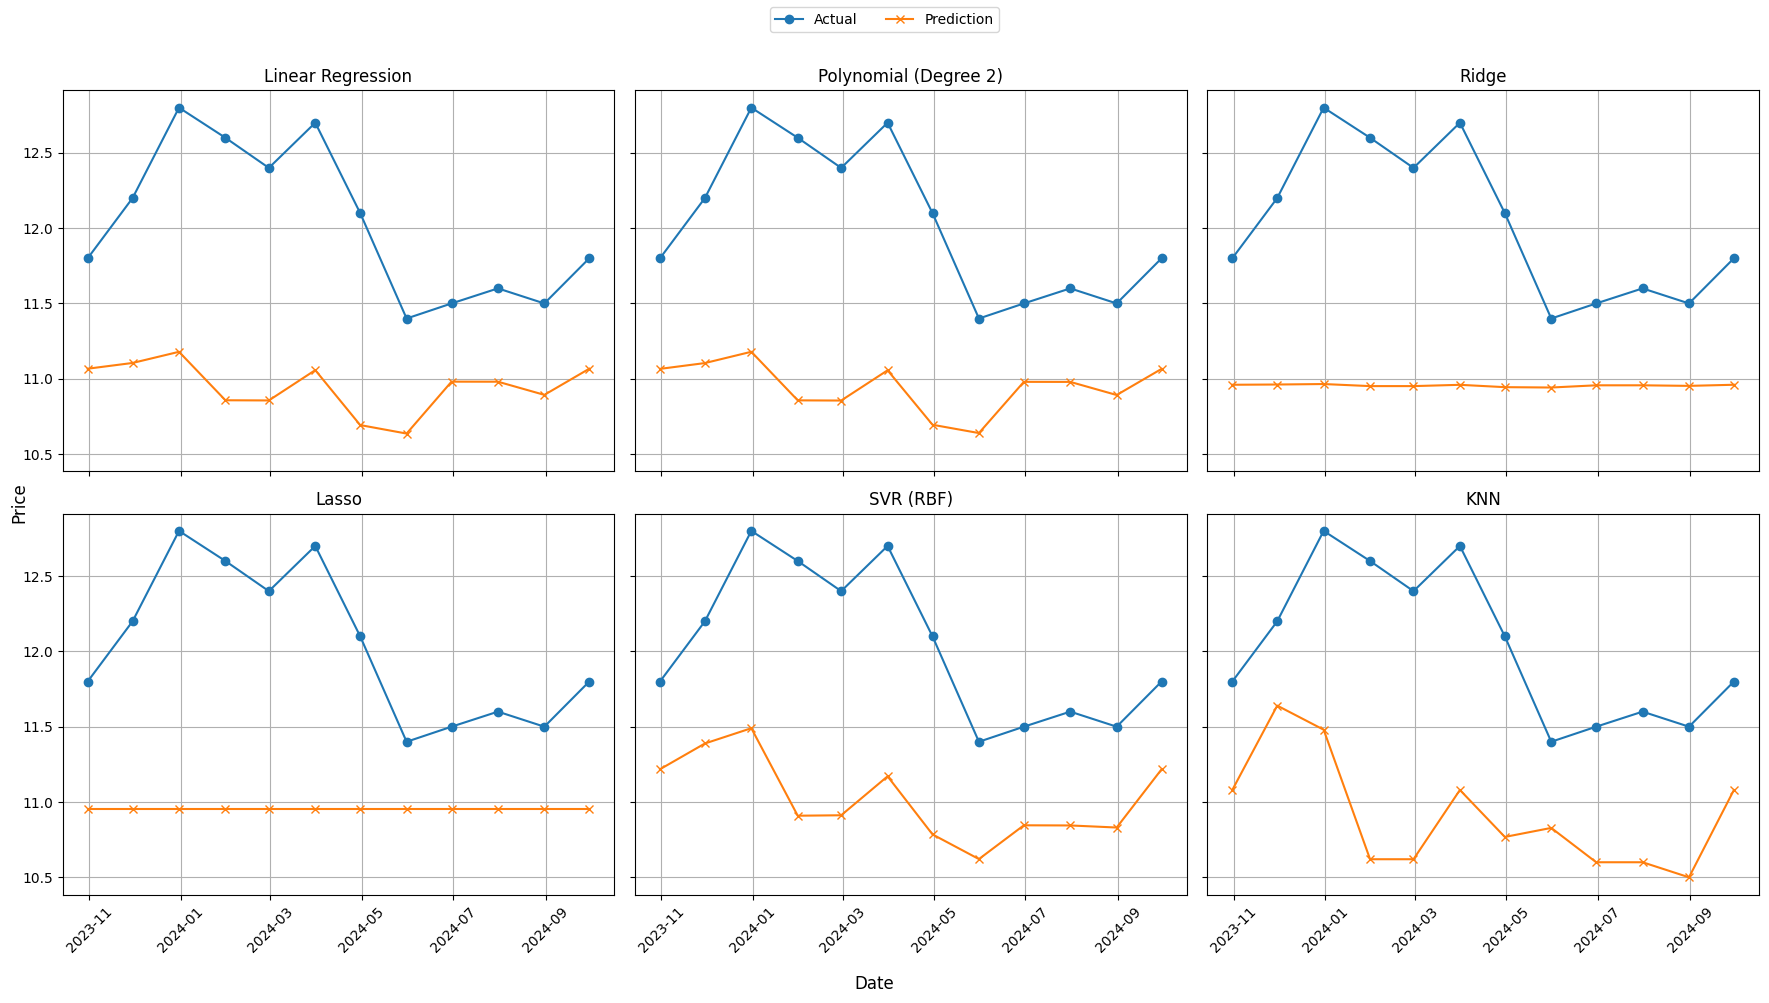

In [293]:
results = []

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    ax = axes[i]

    ax.plot(test_df["Dates"], y_test.values,
            marker='o',
            label="Actual")

    ax.plot(test_df["Dates"], y_pred,
            marker='x',
            label="Prediction")

    ax.set_title(name)
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

# Add common labels
fig.supxlabel("Date")
fig.supylabel("Price")

# One legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [294]:
results = pd.DataFrame(results)

print(results.sort_values("RMSE"))

                   Model       MAE      RMSE        R2
4              SVR (RBF)  1.014081  1.089745 -4.113830
0      Linear Regression  1.085791  1.176458 -4.960041
1  Polynomial (Degree 2)  1.086048  1.176638 -4.961865
2                  Ridge  1.078240  1.180103 -4.997028
3                  Lasso  1.077905  1.180720 -5.003305
5                    KNN  1.125333  1.215093 -5.357922


### 3.4 Experiment B: same idea, now with one lag feature and a naive baseline

A near-repeat of Experiment A, this time with the crucial reference point:

- **Naive baseline** = "next month equals this month" → MAE **0.32**, RMSE **0.38**.
- Every ML model → MAE ~**1.0–1.1**, RMSE ~**1.1–1.2**.

**The naive baseline beats all six models by roughly 3×.** The correlation check confirms `Log_Return` carries only weak information about the price *level*.

In [295]:
df = df.sort_values("Dates").copy()
df["Price_lag_1"] = df["Prices"].shift(1)

# Drop NaNs created by lagging
df = df.dropna().reset_index(drop=True)

In [296]:
forecast_horizon = 12

train_df = df.iloc[:-forecast_horizon]
test_df = df.iloc[-forecast_horizon:]

feature_cols = [
    "Log_Return",
    "Price_lag_1"
]

X_train = train_df[feature_cols]
y_train = train_df["Prices"]

X_test = test_df[feature_cols]
y_test = test_df["Prices"]

In [297]:
print(f"Training period: {train_df['Dates'].min().date()} -> {train_df['Dates'].max().date()}")
print(f"Testing period : {test_df['Dates'].min().date()} -> {test_df['Dates'].max().date()}")

print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")

Training period: 2020-12-31 -> 2023-09-30
Testing period : 2023-10-31 -> 2024-09-30
Training samples: 34
Testing samples : 12


In [298]:
models = {
    "Linear Regression": LinearRegression(),

    "Polynomial (deg 2)": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("lr", LinearRegression())
    ]),

    "Ridge": Ridge(alpha=1.0),

    "Lasso": Lasso(alpha=0.01),

    "SVR (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf"))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=5))
    ])
}

In [299]:
results = {}
metrics = []

for name, model in models.items():

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results[name] = pred

    metrics.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })

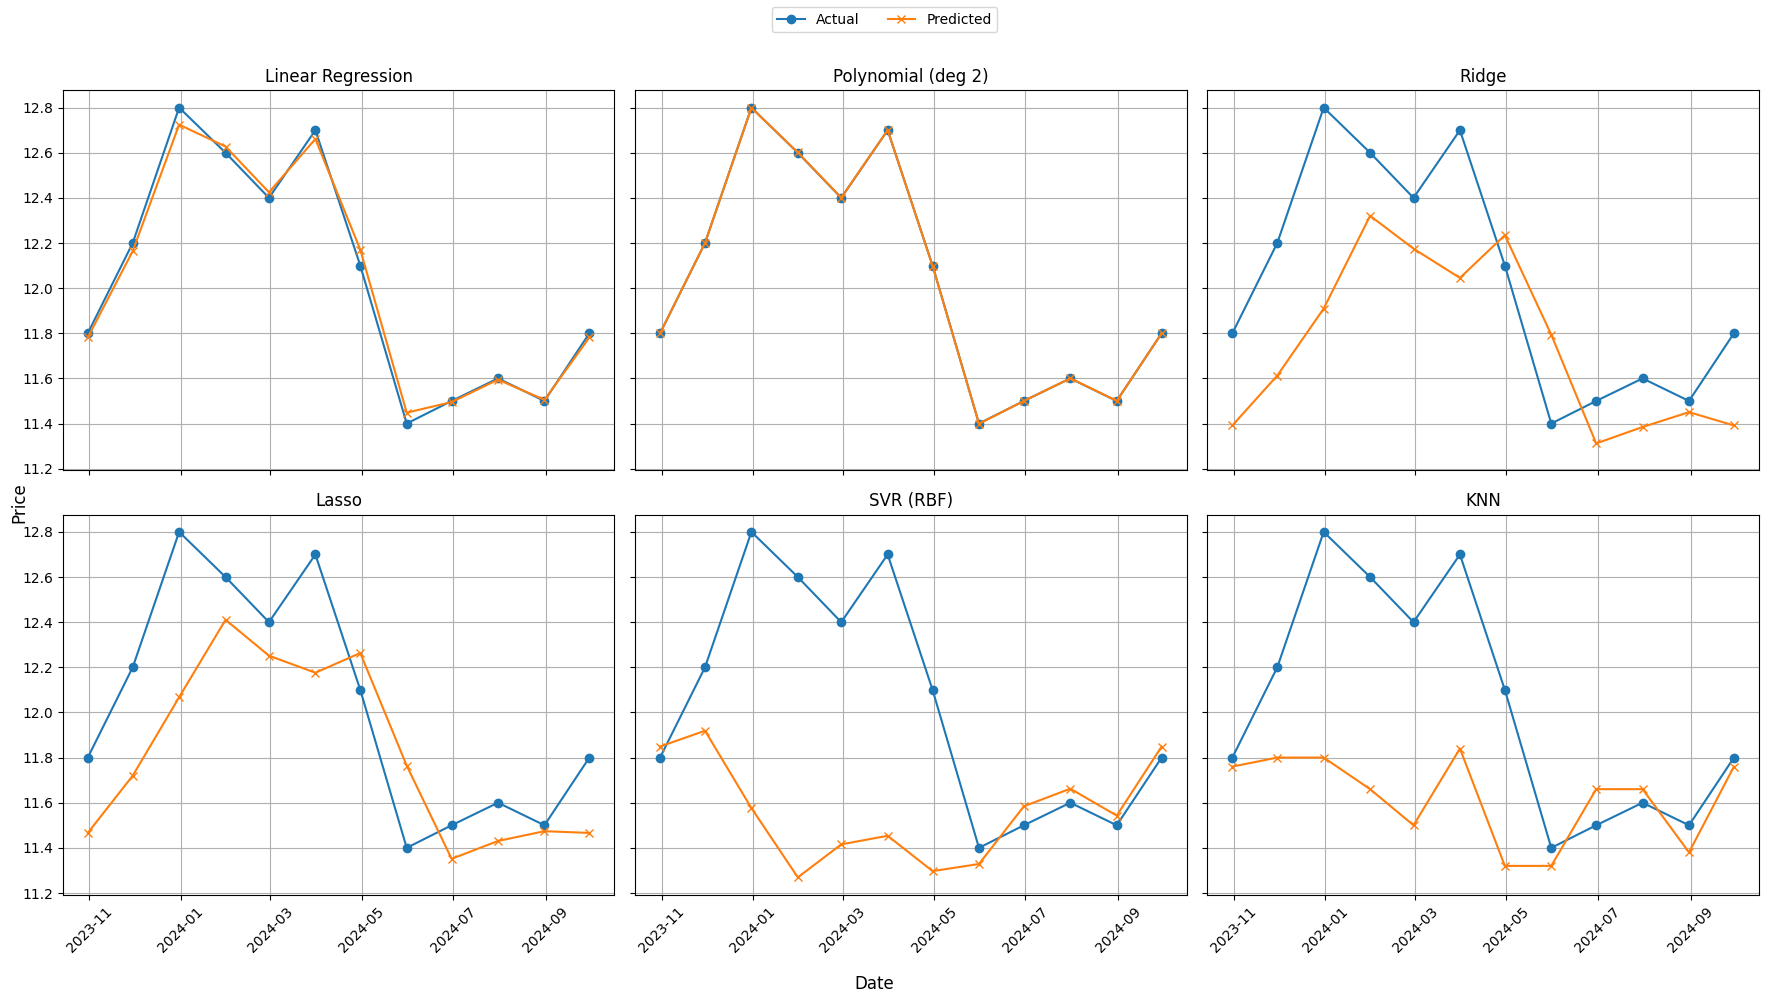

In [300]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, (name, pred) in enumerate(results.items()):

    ax = axes[i]
    ax.plot(test_df["Dates"], y_test.values, label="Actual", marker="o")
    ax.plot(test_df["Dates"], pred, label="Predicted", marker="x")

    ax.set_title(name)
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

# Global labels
fig.supxlabel("Date")
fig.supylabel("Price")

# Single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [301]:
# ----------------------------
# Naive baseline (very important)
# ----------------------------
naive_pred_test = np.roll(y_test, 1)
naive_pred_test[0] = y_train.iloc[-1]  # first step uses last train value

# ----------------------------
# Metrics helper
# ----------------------------
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name}")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print()

# ----------------------------
# Compare baseline vs model
# ----------------------------
evaluate("Naive Baseline", y_test, naive_pred_test)

for name, pred in results.items():
    evaluate(name, y_test, pred)

Naive Baseline
MAE : 0.3249999999999999
RMSE: 0.38188130791298663

Linear Regression
MAE : 0.03109379792873475
RMSE: 0.03858650635993

Polynomial (deg 2)
MAE : 0.0006226172256106702
RMSE: 0.0007521754137349127

Ridge
MAE : 0.36966556458272093
RMSE: 0.4365454725826347

Lasso
MAE : 0.30119435780045184
RMSE: 0.35747947775270106

SVR (RBF)
MAE : 0.5190596855391844
RMSE: 0.7381809095549977

KNN
MAE : 0.4483333333333334
RMSE: 0.5954550080960493



In [302]:
import pandas as pd

metrics_df = pd.DataFrame(metrics).sort_values("RMSE")
print(metrics_df)

                Model       MAE      RMSE        R2
1  Polynomial (deg 2)  0.000623  0.000752  0.999998
0   Linear Regression  0.031094  0.038587  0.993588
3               Lasso  0.301194  0.357479  0.449701
2               Ridge  0.369666  0.436545  0.179355
5                 KNN  0.448333  0.595455 -0.526842
4           SVR (RBF)  0.519060  0.738181 -1.346507


In [303]:
print(train_df.corr()["Prices"].sort_values(ascending=False))

Prices         1.000000
Price_lag_1    0.782970
Dates          0.536782
Log_Return     0.320995
Name: Prices, dtype: float64


### 3.5 Experiment C, recursive 12-month forecast with more lag features (effect of them is not as price_lag_1 effect)

Push the models forward autoregressively (feed each prediction back in) to build a real 12-month forecast:

- All models flatten out and hug the **~11.2 mean** within a month or two.
- They've learned essentially **no seasonal structure**, the opposite of the sine model.

The forecast table makes it concrete: the columns barely move.

In [304]:
df = df.sort_values("Dates").copy()
df["Price_lag_1"] = df["Prices"].shift(1)
df["Price_lag_2"] = df["Prices"].shift(2)
df["Price_lag_3"] = df["Prices"].shift(3)

df["Return_lag_1"] = df["Log_Return"].shift(1)
df["Return_lag_2"] = df["Log_Return"].shift(2)

df = df.dropna().reset_index(drop=True)

feature_cols = [
    "Log_Return",
    "Price_lag_1",
    "Price_lag_2",
    "Price_lag_3",
    "Return_lag_1",
    "Return_lag_2",
]

X = df[feature_cols]
y = df["Prices"]

In [305]:
models = {
    "Linear": LinearRegression(),

    "Poly2": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("lr", LinearRegression())
    ]),

    "Ridge": Ridge(alpha=1.0),

    "Lasso": Lasso(alpha=0.01),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf"))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=5))
    ])
}

fitted_models = {}

for name, model in models.items():
    model.fit(X, y)
    fitted_models[name] = model

In [306]:
def forecast_12m(model, df, feature_cols, months=12):
    df_temp = df.copy()
    preds = []

    for _ in range(months):

        X_last = df_temp[feature_cols].iloc[[-1]]
        next_pred = model.predict(X_last)[0]

        preds.append(next_pred)

        # create fake next row
        new_row = df_temp.iloc[-1].copy()

        new_row["Prices"] = next_pred

        # update features
        new_row["Log_Return"] = np.log(next_pred / df_temp["Prices"].iloc[-1])


        df_temp = pd.concat([df_temp, pd.DataFrame([new_row])], ignore_index=True)

    return np.array(preds)

In [307]:
future_preds = {}

for name, model in fitted_models.items():
    future_preds[name] = forecast_12m(model, df, feature_cols, months=12)

In [308]:
future_dates = pd.date_range(
    start=df["Dates"].iloc[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="M"
)

C:\Users\aqeel\AppData\Local\Temp\ipykernel_15876\1569170734.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


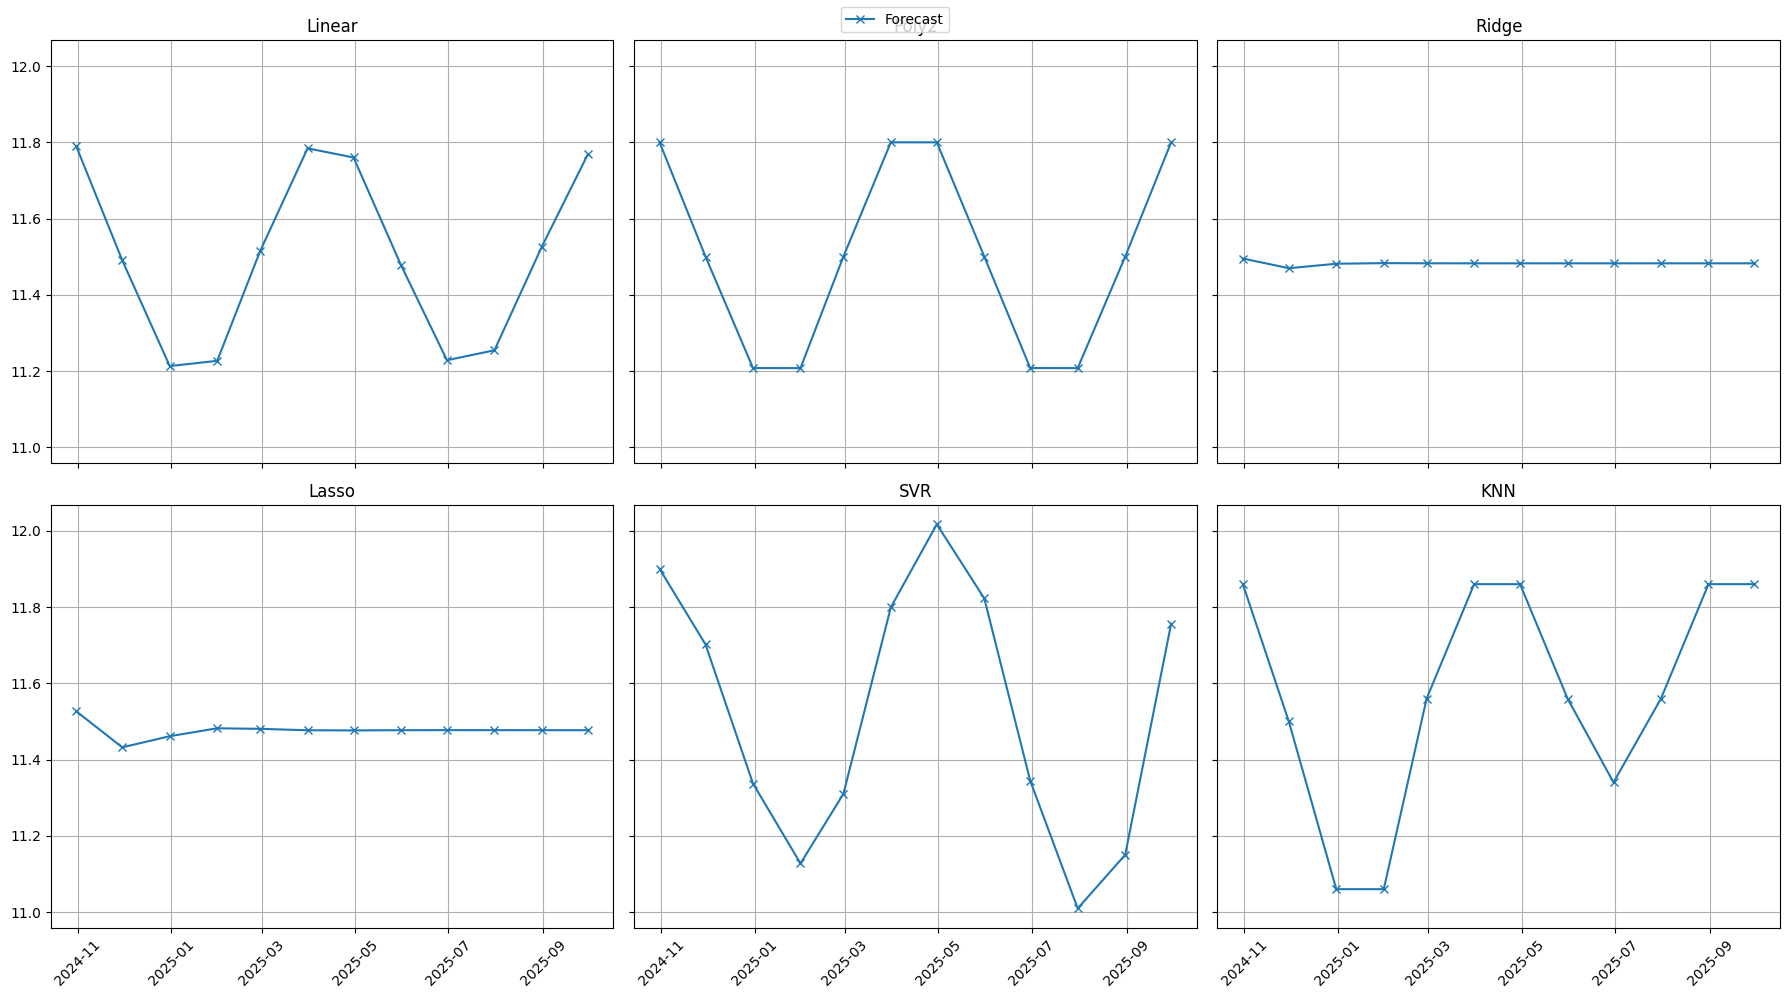

In [309]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, (name, preds) in enumerate(future_preds.items()):

    ax = axes[i]

    # forecast
    ax.plot(future_dates, preds, marker="x", label="Forecast")

    ax.set_title(name)
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout()
plt.show()

In [310]:
forecast_table = pd.DataFrame(future_preds, index=future_dates)
print(forecast_table)

               Linear      Poly2      Ridge      Lasso        SVR    KNN
2024-10-31  11.789268  11.799981  11.495154  11.526578  11.900208  11.86
2024-11-30  11.490497  11.500208  11.469769  11.431993  11.701854  11.50
2024-12-31  11.213051  11.207854  11.481484  11.461225  11.337004  11.06
2025-01-31  11.226804  11.207659  11.483064  11.481977  11.127453  11.06
2025-02-28  11.514429  11.500025  11.482632  11.480545  11.309825  11.56
2025-03-31  11.784161  11.799974  11.482546  11.476827  11.799459  11.86
2025-04-30  11.760166  11.799929  11.482561  11.476444  12.017065  11.86
2025-05-31  11.477853  11.500183  11.482565  11.477003  11.822673  11.56
2025-06-30  11.228409  11.207879  11.482565  11.477160  11.344386  11.34
2025-07-31  11.254479  11.207708  11.482565  11.477093  11.009520  11.56
2025-08-31  11.526680  11.500050  11.482565  11.477055  11.150204  11.86
2025-09-30  11.768489  11.799948  11.482565  11.477060  11.756379  11.86


### 3.6 More variants, same verdict

The remaining blocks are minor re-runs of the same experiment with small tweaks:

- A consolidated all-in-one train / predict / score.
- **Time-index only** as the feature (adds a Poly3).
- **Returns as the target** instead of price, then reconstructing the price path.

All converge on the same picture: flat, mean-reverting forecasts and negative R². Nothing the machine does improves on the eyeballed seasonal shape.

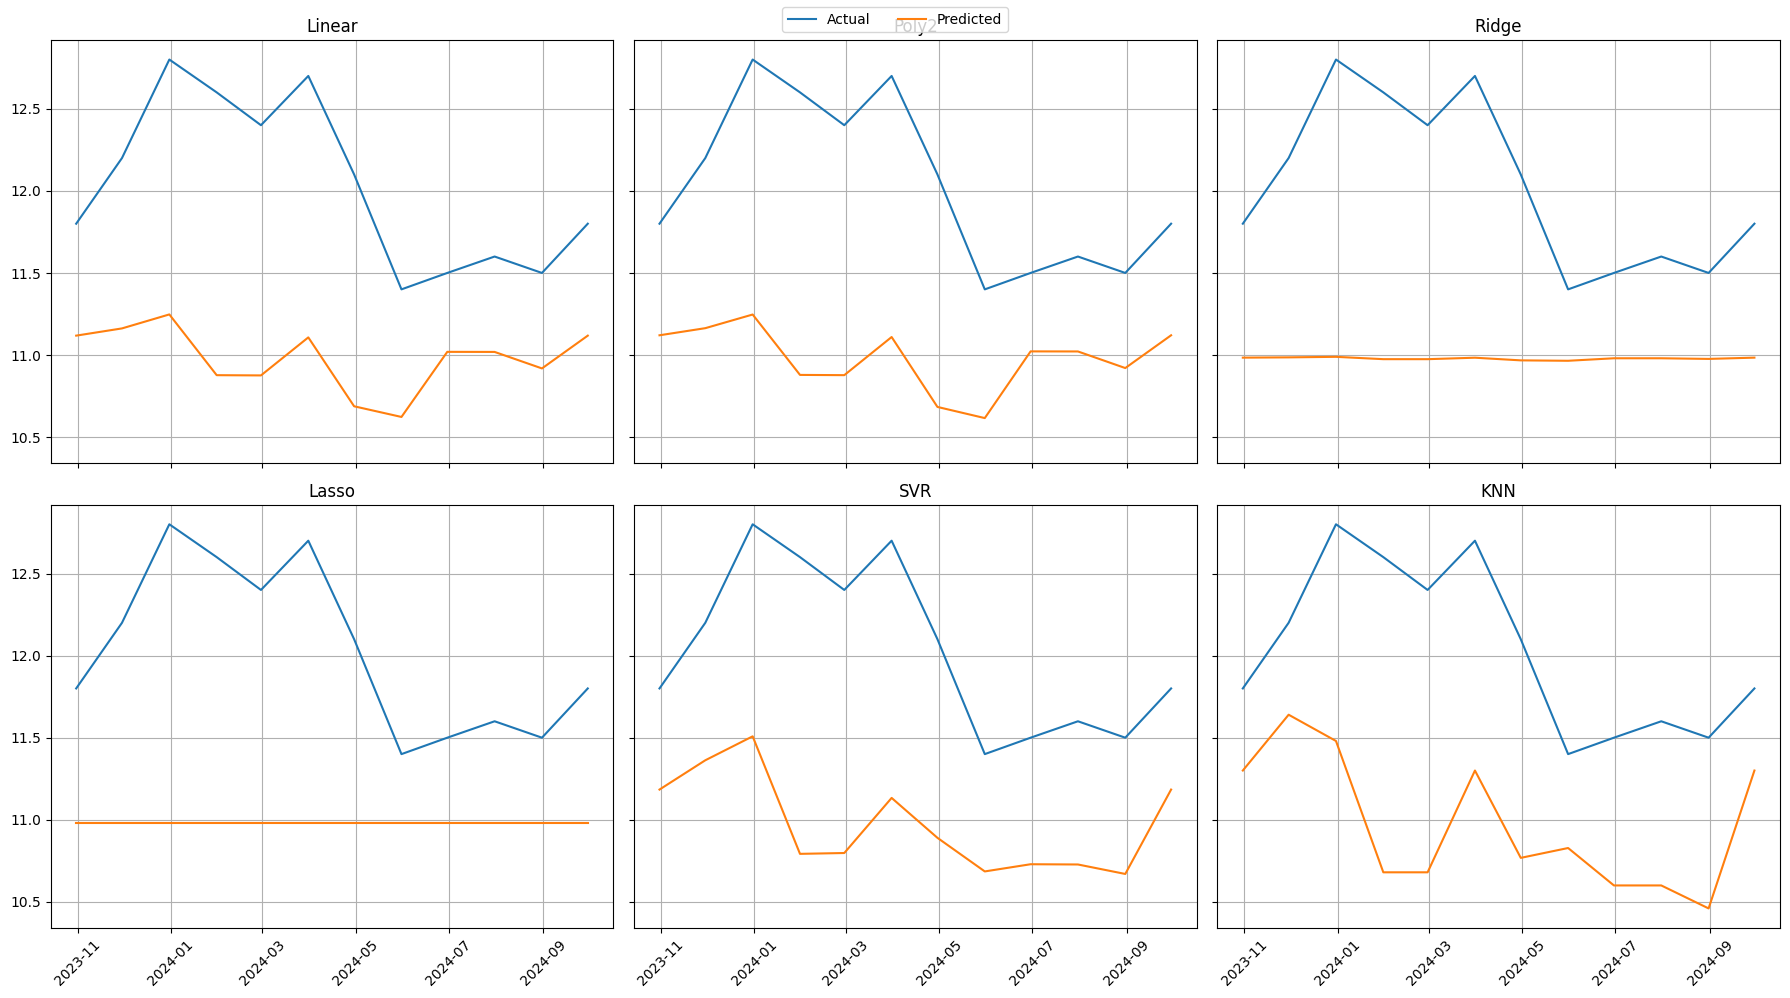

    Model       MAE      RMSE        R2
4     SVR  1.061322  1.134233 -4.539884
1   Poly2  1.051548  1.145229 -4.647819
0  Linear  1.052200  1.145654 -4.652009
2   Ridge  1.054530  1.158442 -4.778894
3   Lasso  1.054624  1.159506 -4.789512
5     KNN  1.063667  1.160237 -4.796821


In [311]:
# ----------------------------
# 1. Prepare data
# ----------------------------
df = df.sort_values("Dates").copy()
df = df.dropna().reset_index(drop=True)

forecast_horizon = 12

train_df = df.iloc[:-forecast_horizon]
test_df = df.iloc[-forecast_horizon:]

# IMPORTANT: you can toggle features here
feature_cols = ["Log_Return"]   # try removing Log_Return later if you want experiment

X_train = train_df[feature_cols]
y_train = train_df["Prices"]

X_test = test_df[feature_cols]
y_test = test_df["Prices"]

# ----------------------------
# 2. Models
# ----------------------------
models = {
    "Linear": LinearRegression(),

    "Poly2": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("lr", LinearRegression())
    ]),

    "Ridge": Ridge(alpha=1.0),

    "Lasso": Lasso(alpha=0.01),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf"))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=5))
    ])
}

# ----------------------------
# 3. Train + predict
# ----------------------------
results = {}
metrics = []

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results[name] = pred

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    metrics.append([name, mae, rmse, r2])

    ax = axes[i]

    ax.plot(test_df["Dates"], y_test.values, label="Actual")
    ax.plot(test_df["Dates"], pred, label="Predicted")

    ax.set_title(name)
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

# ----------------------------
# 4. Legend + layout
# ----------------------------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout()
plt.show()

# ----------------------------
# 5. Metrics table
# ----------------------------
metrics_df = pd.DataFrame(metrics, columns=["Model", "MAE", "RMSE", "R2"])
print(metrics_df.sort_values("RMSE"))

C:\Users\aqeel\AppData\Local\Temp\ipykernel_15876\2899997961.py:55: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


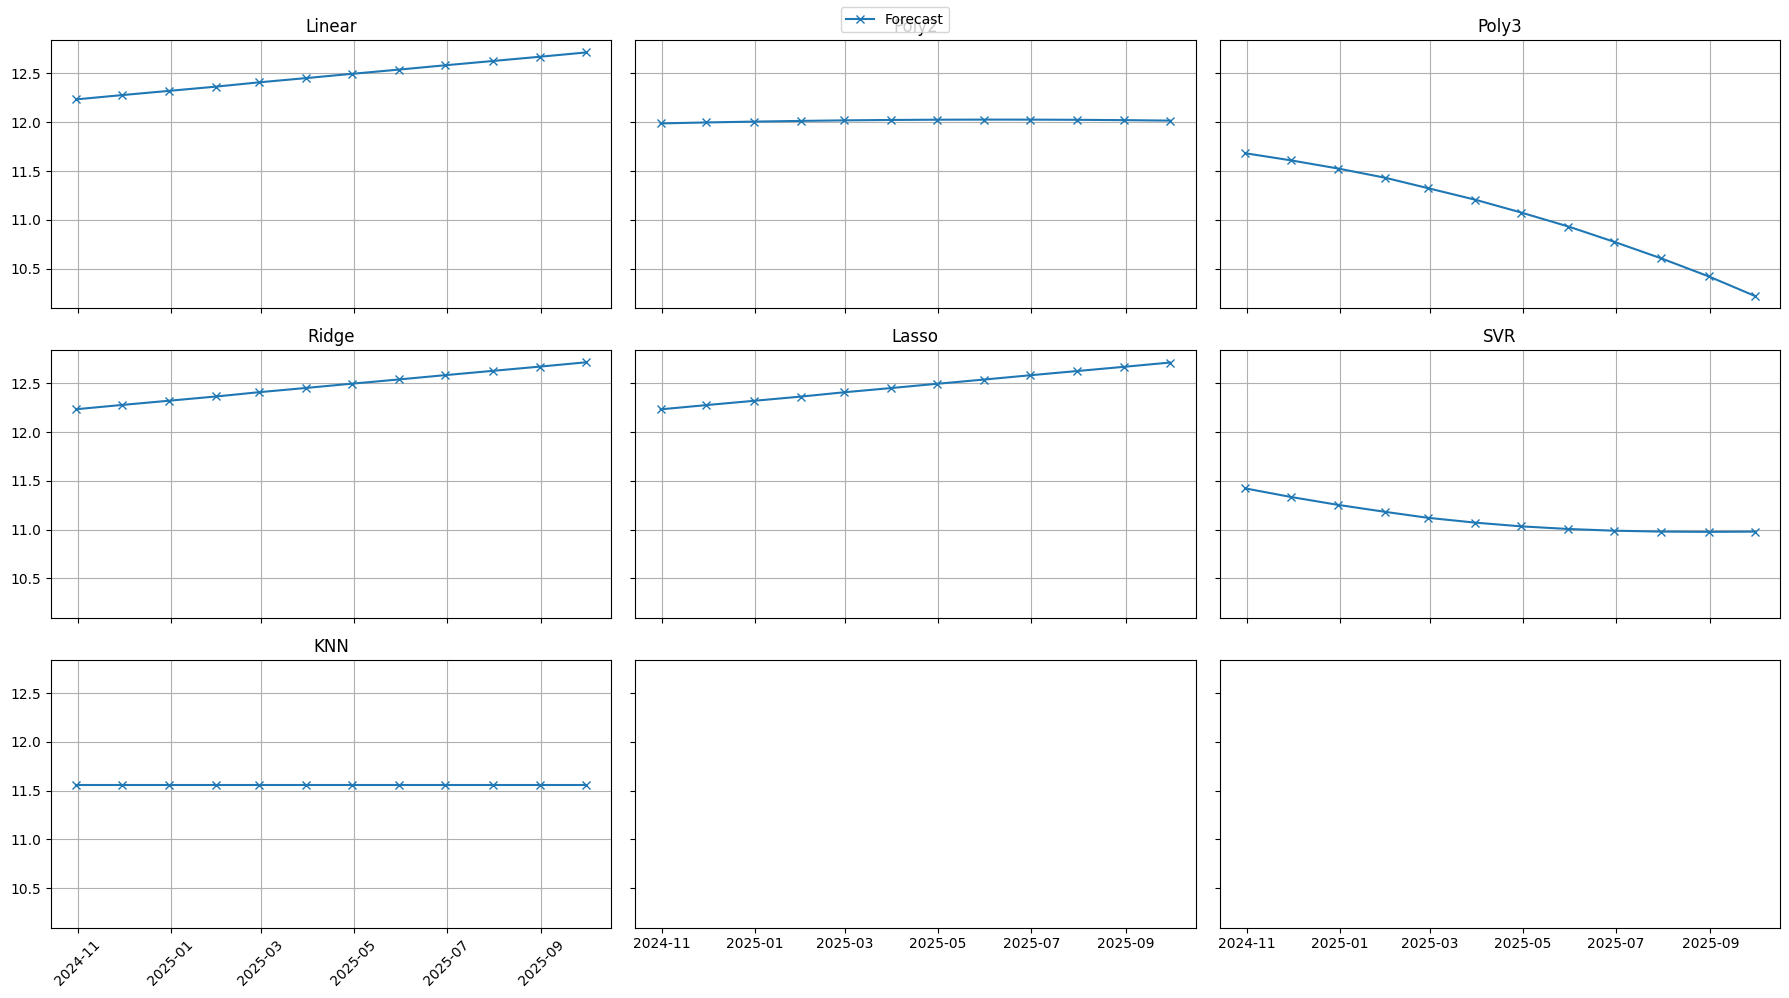

               Linear      Poly2      Poly3      Ridge      Lasso        SVR  \
2024-10-31  12.233621  11.987361  11.682358  12.233476  12.232193  11.423081   
2024-11-30  12.277285  11.997443  11.609258  12.277133  12.275791  11.334712   
2024-12-31  12.320948  12.006033  11.525423  12.320790  12.319390  11.253564   
2025-01-31  12.364612  12.013131  11.430451  12.364447  12.362989  11.181848   
2025-02-28  12.408275  12.018736  11.323941  12.408104  12.406587  11.120993   
2025-03-31  12.451939  12.022849  11.205489  12.451761  12.450186  11.071650   
2025-04-30  12.495603  12.025469  11.074696  12.495418  12.493784  11.033749   
2025-05-31  12.539266  12.026597  10.931158  12.539075  12.537383  11.006620   
2025-06-30  12.582930  12.026232  10.774474  12.582732  12.580982  10.989137   
2025-07-31  12.626593  12.024374  10.604243  12.626389  12.624580  10.979870   
2025-08-31  12.670257  12.021025  10.420061  12.670046  12.668179  10.977244   
2025-09-30  12.713920  12.016182  10.221

In [312]:
# ----------------------------
# 1. Prepare pure price data
# ----------------------------
df = df.sort_values("Dates").copy()
df = df.dropna().reset_index(drop=True)

X = np.arange(len(df)).reshape(-1, 1)   # time index ONLY
y = df["Prices"].values

# ----------------------------
# 2. Models
# ----------------------------
models = {
    "Linear": LinearRegression(),

    "Poly2": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("lr", LinearRegression())
    ]),

    "Poly3": Pipeline([
        ("poly", PolynomialFeatures(degree=3)),
        ("lr", LinearRegression())
    ]),

    "Ridge": Ridge(alpha=1.0),

    "Lasso": Lasso(alpha=0.01),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf"))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=5))
    ])
}

# ----------------------------
# 3. Fit models
# ----------------------------
fitted = {}
for name, model in models.items():
    model.fit(X, y)
    fitted[name] = model

# ----------------------------
# 4. Recursive 12-month forecast
# ----------------------------
future_steps = 12
future_X = np.arange(len(df), len(df) + future_steps).reshape(-1, 1)

future_dates = pd.date_range(
    start=df["Dates"].iloc[-1] + pd.DateOffset(months=1),
    periods=future_steps,
    freq="M"
)

predictions = {}

for name, model in fitted.items():
    preds = model.predict(future_X)
    predictions[name] = preds

# ----------------------------
# 5. Visualization (grid)
# ----------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, (name, preds) in enumerate(predictions.items()):

    ax = axes[i]

    ax.plot(future_dates, preds, marker="x", label="Forecast")

    ax.set_title(name)
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

# legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout()
plt.show()

# ----------------------------
# 6. Output forecast table
# ----------------------------
forecast_df = pd.DataFrame(predictions, index=future_dates)
print(forecast_df)

In [313]:
# ----------------------------
# Naive baseline (very important)
# ----------------------------
naive_pred_test = np.roll(y_test, 1)
naive_pred_test[0] = y_train.iloc[-1]  # first step uses last train value

# ----------------------------
# Metrics helper
# ----------------------------
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name}")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print()

# ----------------------------
# Compare baseline vs model
# ----------------------------
evaluate("Naive Baseline", y_test, naive_pred_test)

for name, pred in results.items():
    evaluate(name, y_test, pred)

Naive Baseline
MAE : 0.3249999999999999
RMSE: 0.38188130791298663

Linear
MAE : 1.0522003259758472
RMSE: 1.1456536013764975

Poly2
MAE : 1.0515482665303157
RMSE: 1.145228855672875

Ridge
MAE : 1.0545303108019113
RMSE: 1.15844190924831

Lasso
MAE : 1.0546236559139788
RMSE: 1.1595056178542595

SVR
MAE : 1.0613217270848112
RMSE: 1.134232854931038

KNN
MAE : 1.063666666666667
RMSE: 1.1602373320431763



C:\Users\aqeel\AppData\Local\Temp\ipykernel_15876\42878509.py:54: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


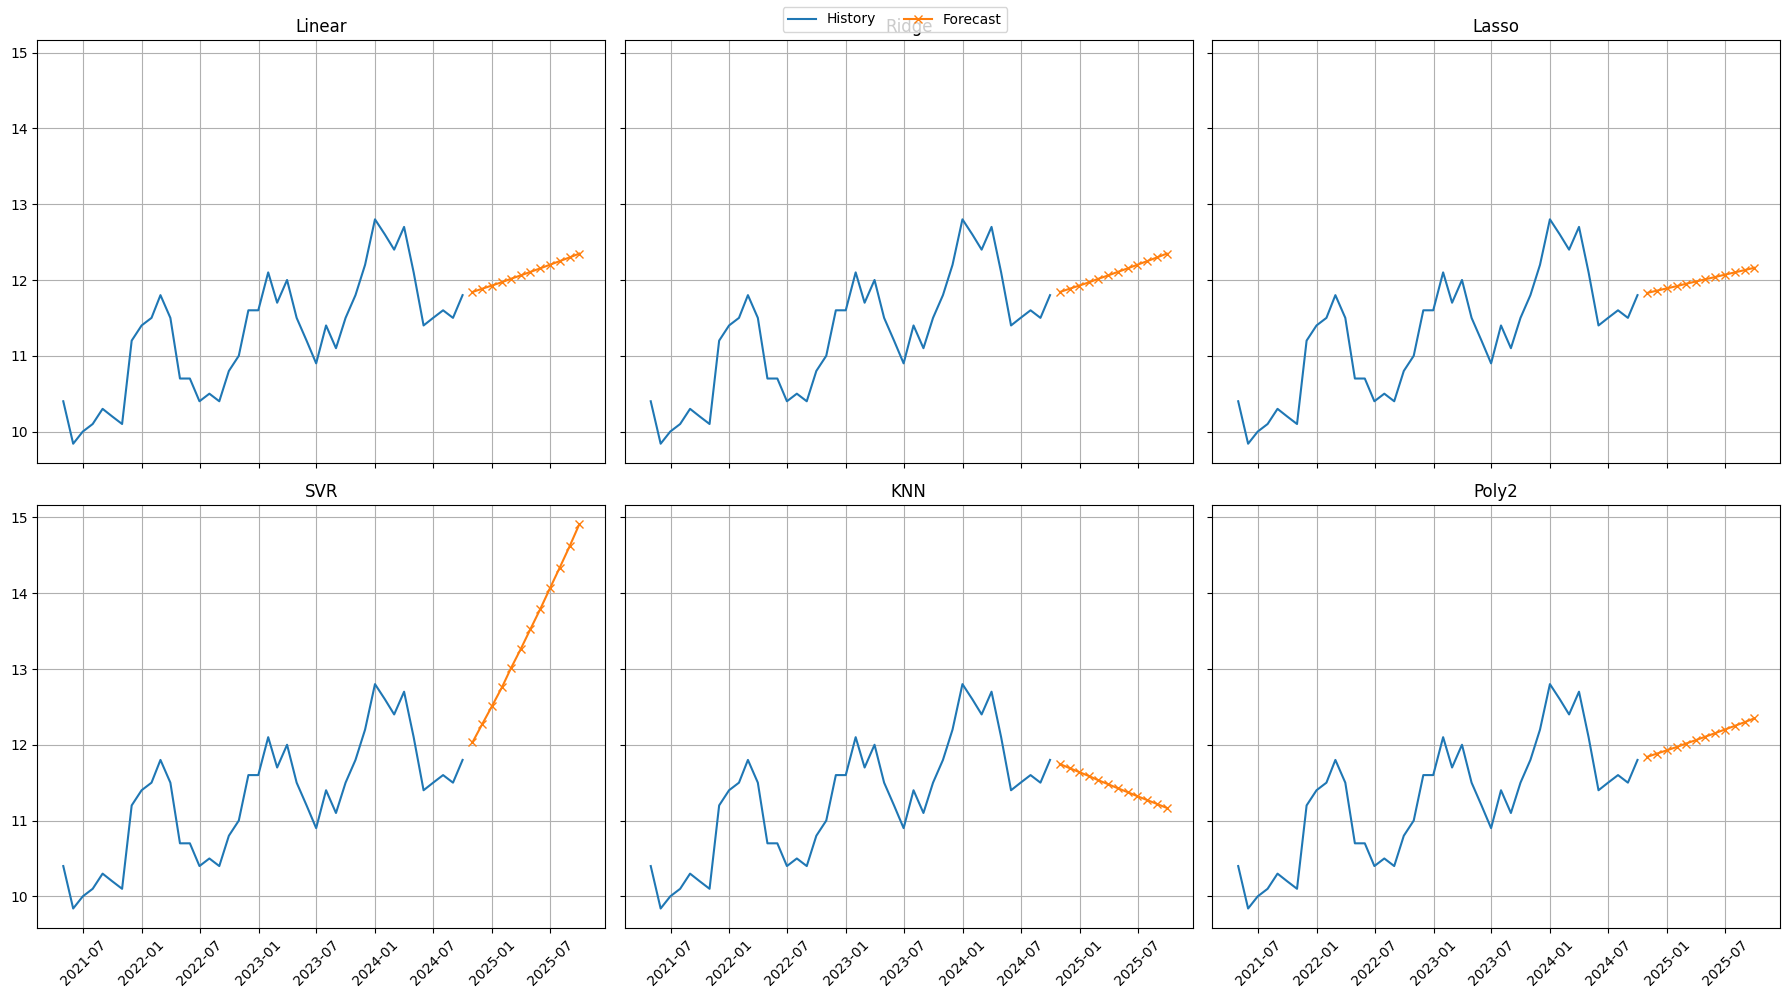

               Linear      Ridge      Lasso        SVR        KNN      Poly2
2024-10-31  11.841637  11.841635  11.829637  12.032139  11.745915  11.841637
2024-11-30  11.883982  11.883978  11.859349  12.268846  11.692078  11.883982
2024-12-31  11.927040  11.927034  11.889135  12.510209  11.638487  11.927040
2025-01-31  11.970818  11.970810  11.918996  12.756320  11.585143  11.970818
2025-02-28  12.015323  12.015312  11.948932  13.007273  11.532042  12.015323
2025-03-31  12.060562  12.060549  11.978943  13.263163  11.479186  12.060562
2025-04-30  12.106542  12.106526  12.009030  13.524087  11.426571  12.106542
2025-05-31  12.153269  12.153251  12.039192  13.790144  11.374198  12.153269
2025-06-30  12.200752  12.200731  12.069430  14.061436  11.322064  12.200752
2025-07-31  12.248998  12.248973  12.099744  14.338064  11.270170  12.248998
2025-08-31  12.298013  12.297986  12.130134  14.620134  11.218513  12.298013
2025-09-30  12.347807  12.347776  12.160600  14.907754  11.167093  12.347807

In [314]:
# ----------------------------
# 1. Prepare data
# ----------------------------
df = df.sort_values("Dates").copy()

# convert to returns (TARGET CHANGE)
df["Return"] = df["Prices"].pct_change()
df = df.dropna().reset_index(drop=True)

# features: time index ONLY (clean baseline)
X = np.arange(len(df)).reshape(-1, 1)
y = df["Return"].values

# ----------------------------
# 2. Models
# ----------------------------
models = {
    "Linear": LinearRegression(),

    "Ridge": Ridge(alpha=1.0),

    "Lasso": Lasso(alpha=0.01),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf"))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=5))
    ]),

    "Poly2": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", LinearRegression())  # kept simple; avoid instability in returns space
    ])
}

# ----------------------------
# 3. Fit models on FULL data
# ----------------------------
fitted = {}
for name, model in models.items():
    model.fit(X, y)
    fitted[name] = model

# ----------------------------
# 4. Recursive forecasting (returns → price)
# ----------------------------
future_steps = 12
future_X = np.arange(len(df), len(df) + future_steps).reshape(-1, 1)

future_dates = pd.date_range(
    start=df["Dates"].iloc[-1] + pd.DateOffset(months=1),
    periods=future_steps,
    freq="M"
)

results = {}

for name, model in fitted.items():

    preds = model.predict(future_X)

    # reconstruct price path
    last_price = df["Prices"].iloc[-1]
    price_path = [last_price]

    for r in preds:
        next_price = price_path[-1] * (1 + r)
        price_path.append(next_price)

    results[name] = price_path[1:]

# ----------------------------
# 5. Plot results
# ----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, (name, preds) in enumerate(results.items()):

    ax = axes[i]

    ax.plot(df["Dates"], df["Prices"], label="History")
    ax.plot(future_dates, preds, marker="x", label="Forecast")

    ax.set_title(name)
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

plt.tight_layout()
plt.show()

# ----------------------------
# 6. Output table
# ----------------------------
forecast_df = pd.DataFrame(results, index=future_dates)
print(forecast_df)

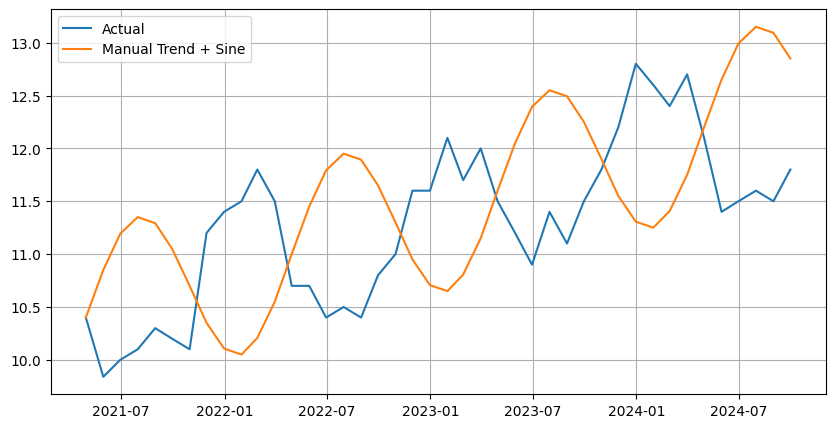

In [315]:
# time index
t = np.arange(len(df))
y = df["Prices"].values

# ----------------------------
# MANUAL PARAMETERS (edit these)
# ----------------------------
a = y[0]          # baseline level
b = 0.05          # slope (trend per step)
A = 0.8           # oscillation amplitude
w = 2 * np.pi / 12  # cycle length (12-month seasonality)
phi = 0           # phase shift

# ----------------------------
# model
# ----------------------------
def model(t):
    return a + b*t + A * np.sin(w*t + phi)

y_fit = model(t)

# ----------------------------
# plot
# ----------------------------
plt.figure(figsize=(10,5))
plt.plot(df["Dates"], y, label="Actual")
plt.plot(df["Dates"], y_fit, label="Manual Trend + Sine")
plt.legend()
plt.grid(True)
plt.show()

## 4. Conclusion

- The raw series visibly = **gentle trend + yearly cycle**.
- A **hand-built trend + sine** model captures that directly → the submitted solution.
- Six standard regressors, given only a return / time feature:
  - RMSE ~**1.1–1.2**, **R² strongly negative** across the board.
  - All **beaten ~3×** by a naive last-value baseline.
  - Recursive forecasts collapse to the mean, no seasonality learned.
- **Takeaway:** for this small, strongly seasonal series, the human structural assumption (sine) outperforms off-the-shelf ML that was never handed seasonal features. The machine had its say, and it agreed the eye was right.